# 04 - Supervised Sentiment Classification
## Customer Feedback Intelligence System

### Objectives:
- Train baseline and ensemble classification models:
  1. Logistic Regression (Linear Model with Class Weighting).
  2. Random Forest Classifier (Tree Ensemble Model).
- Evaluate models using Precision, Recall, Macro F1-score, and Confusion Matrix.
- Select the top-performing model and serialize it for the FastAPI backend.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import joblib

DATA_PATH = Path("../data/processed/cleaned_reviews.csv")
MODELS_DIR = Path("../models")
FIGURES_PATH = Path("../reports/figures")

df = pd.read_csv(DATA_PATH)
vectorizer = joblib.load(MODELS_DIR / "tfidf_vectorizer.pkl")

In [2]:
# 1. Prepare Target Variable
# Target mapping: 0 -> Negative, 1 -> Neutral, 2 -> Positive
def encode_target(rating):
    if rating <= 2:
        return 0
    elif rating == 3:
        return 1
    return 2

df["Target"] = df["Rating"].apply(encode_target)

# Clean input texts using basic normalization before vectorization
X = vectorizer.transform(df["Review Text"].fillna("").astype(str).str.lower())
y = df["Target"].values

# 2. Stratified Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")

Train Shape: (18100, 5000), Test Shape: (4526, 5000)


In [3]:
# 3. Model 1: Logistic Regression with Class Weighting
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    C=1.0,
    random_state=42
)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
print("=== Logistic Regression Performance Report ===")
print(classification_report(y_test, y_pred_lr, target_names=["Negative", "Neutral", "Positive"]))

=== Logistic Regression Performance Report ===
              precision    recall  f1-score   support

    Negative       0.46      0.59      0.52       474
     Neutral       0.32      0.47      0.39       565
    Positive       0.95      0.84      0.89      3487

    accuracy                           0.77      4526
   macro avg       0.58      0.64      0.60      4526
weighted avg       0.82      0.77      0.79      4526



In [4]:
# 4. Model 2: Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=25,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print("=== Random Forest Performance Report ===")
print(classification_report(y_test, y_pred_rf, target_names=["Negative", "Neutral", "Positive"]))

=== Random Forest Performance Report ===
              precision    recall  f1-score   support

    Negative       0.43      0.55      0.48       474
     Neutral       0.32      0.33      0.32       565
    Positive       0.92      0.87      0.89      3487

    accuracy                           0.77      4526
   macro avg       0.56      0.59      0.57      4526
weighted avg       0.79      0.77      0.78      4526



Logistic Regression Macro F1: 0.5992
Random Forest Macro F1:       0.5679


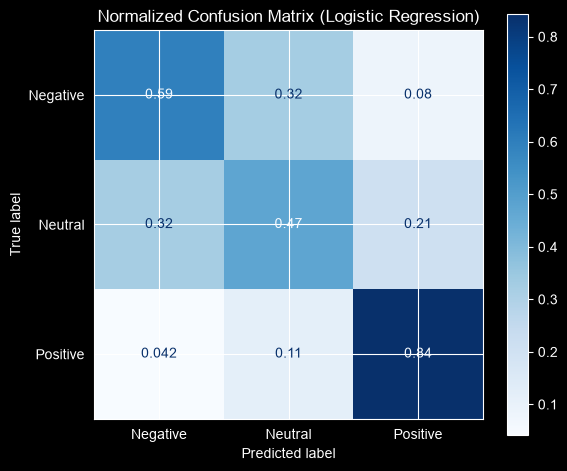

Saved best classifier to models/logistic_regression_model.pkl


In [5]:
# 5. Comparative Evaluation and Confusion Matrix Plot
f1_lr = f1_score(y_test, y_pred_lr, average="macro")
f1_rf = f1_score(y_test, y_pred_rf, average="macro")

print(f"Logistic Regression Macro F1: {f1_lr:.4f}")
print(f"Random Forest Macro F1:       {f1_rf:.4f}")

# Plot Confusion Matrix for the best model
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=["Negative", "Neutral", "Positive"],
    cmap="Blues",
    normalize="true",
    ax=ax
)
plt.title("Normalized Confusion Matrix (Logistic Regression)")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "confusion_matrix_lr.png")
plt.show()

# 6. Save the production sentiment classifier
joblib.dump(lr_model, MODELS_DIR / "logistic_regression_model.pkl")
print("Saved best classifier to models/logistic_regression_model.pkl")